In [132]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.loader import load_specs
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level, load_trading_model_3level
from tradepy.supervised.backtest import prepare_bt, create_test_dataset, predict_in_batches, run_backtest_complete, run_backtest_complete_scalein, run_backtest_sizing_only, run_backtest_scalein_sizing, build_overlapping_blocks, monte_carlo_blocks
from tradepy.paths import MODELS_DIR, BT_DIR

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt


In [133]:
symbols = load_symbols()
cfg = load_config()

In [134]:
symbols

['AD',
 'BP',
 'CL',
 'EC',
 'ES',
 'GC',
 'MFXI',
 'NG',
 'NQ',
 'YM',
 'ZB',
 'ZN',
 'ZS']

In [135]:
ASSET = symbols[5]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [136]:
(
    model_l1,
    model_l2,
    model_l3,
    sc_features,
    sc_l3,
    features,
    params,
    thresholds,
    df_results
) = load_trading_model_3level(
        BasicLSTM_L1_Move,
        BasicLSTM_L2_Dir,
        BasicLSTM_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_lstm_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/trading_model_lstm_3level
📌 Features: 71
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [137]:
(
    model_l1_g,
    model_l2_g,
    model_l3_g,
    sc_features_g,
    sc_l3_g,
    features_g,
    params_g,
    thresholds_g,
    df_results_g
) = load_trading_model_3level(
        BasicGRU_L1_Move,
        BasicGRU_L2_Dir,
        BasicGRU_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_gru_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/trading_model_gru_3level
📌 Features: 71
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [138]:
ASSET

'GC'

In [139]:
df_bt, spec_bt = prepare_bt(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")

In [140]:
df_bt

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,nearest_fib_level,dist_to_nearest_fib,swing_extension,bars_between_swing_highs,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker
0,2025-12-26 00:00:00+00:00,4572.9,4593.9,4572.9,4593.6,38.0,0.0,240min,2025-12-25,4572.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
1,2025-12-26 04:00:00+00:00,4600.0,4625.7,4590.0,4606.6,110.0,0.0,240min,2025-12-26,4600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
2,2025-12-26 08:00:00+00:00,4599.6,4612.3,4599.6,4602.8,62.0,0.0,240min,2025-12-26,4600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
3,2025-12-26 12:00:00+00:00,4605.8,4619.5,4598.0,4599.8,82.0,0.0,240min,2025-12-26,4600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
4,2025-12-26 16:00:00+00:00,4599.8,4645.9,4599.8,4645.9,238.0,0.0,240min,2025-12-26,4600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764,2026-06-19 04:00:00+00:00,4183.3,4188.9,4171.1,4171.2,19.0,0.0,240min,2026-06-19,4183.3,...,0.236,-1.190416,-1.954416,4.0,8.0,16.475,13.162500,1.0,6.000,GC
765,2026-06-19 08:00:00+00:00,4171.2,4171.2,4171.2,4171.2,0.0,0.0,240min,2026-06-19,4183.3,...,0.236,-1.190416,-1.954416,4.0,8.0,16.475,13.162500,1.0,7.000,GC
766,2026-06-19 12:00:00+00:00,4171.2,4171.2,4171.2,4171.2,0.0,0.0,240min,2026-06-19,4183.3,...,0.236,-0.235514,-0.999514,4.0,7.0,16.475,29.414286,8.0,1.000,GC
767,2026-06-19 16:00:00+00:00,4171.2,4171.2,4141.1,4146.8,46.0,0.0,240min,2026-06-19,4183.3,...,0.236,-0.354018,-1.118018,4.0,7.0,16.475,29.414286,8.0,1.125,GC


In [141]:
# start = "2026-03-27"
start = "2026-01-20"
end   = "2026-06-01"

mask = (df_bt["datetime"] >= start) & (df_bt["datetime"] < end)
df_filtered = df_bt.loc[mask]


In [142]:
df_bt["datetime"].dt.hour

0       0
1       4
2       8
3      12
4      16
       ..
764     4
765     8
766    12
767    16
768    20
Name: datetime, Length: 769, dtype: int32

<Axes: ylabel='Frequency'>

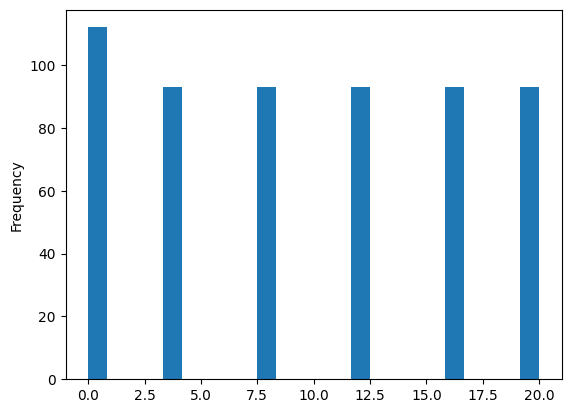

In [143]:
df_filtered["hour"] = df_filtered["datetime"].dt.hour
df_filtered["hour"].plot.hist(bins=24)


In [144]:
test, test_dt = create_test_dataset(df_filtered, features, lookback=30)

In [145]:
test_dt

0     2026-01-26 20:00:00+00:00
1     2026-01-27 00:00:00+00:00
2     2026-01-27 04:00:00+00:00
3     2026-01-27 08:00:00+00:00
4     2026-01-27 12:00:00+00:00
                 ...           
542   2026-05-29 08:00:00+00:00
543   2026-05-29 12:00:00+00:00
544   2026-05-29 16:00:00+00:00
545   2026-05-29 20:00:00+00:00
546   2026-05-30 00:00:00+00:00
Name: datetime, Length: 547, dtype: datetime64[us, UTC]

In [146]:
test_g, test_dt_g = create_test_dataset(df_filtered, features_g, lookback=30)

In [147]:
test

array([[[-1.44236961e+01,  0.00000000e+00,  2.50305033e+01, ...,
          1.28836040e-03,  3.81526104e-02,  2.39911308e+01],
        [-5.92401803e+00,  0.00000000e+00,  2.51478381e+01, ...,
          3.69471128e-03,  6.31229236e-02,  3.24675325e+01],
        [-2.82515991e+00,  0.00000000e+00,  2.63278004e+01, ...,
          1.16792329e-02, -4.66417910e-01,  4.76971116e+01],
        ...,
        [-6.68969849e+00,  0.00000000e+00,  4.53954995e+01, ...,
          2.55060487e-02,  1.01832994e+00,  7.84672501e+01],
        [-6.12988734e+00,  0.00000000e+00,  4.67143247e+01, ...,
          2.06287419e-02,  6.75026123e-01,  7.60965558e+01],
        [-4.60569914e+00,  1.00000000e+00,  4.71060312e+01, ...,
          2.09123223e-02,  8.69456901e-01,  7.75504239e+01]],

       [[-5.92401803e+00,  0.00000000e+00,  2.51478381e+01, ...,
          3.69471128e-03,  6.31229236e-02,  3.24675325e+01],
        [-2.82515991e+00,  0.00000000e+00,  2.63278004e+01, ...,
          1.16792329e-02, -4.66417910e

In [148]:
test_flat = test.reshape(-1, test.shape[-1])


In [149]:
test_flat

array([[-1.44236961e+01,  0.00000000e+00,  2.50305033e+01, ...,
         1.28836040e-03,  3.81526104e-02,  2.39911308e+01],
       [-5.92401803e+00,  0.00000000e+00,  2.51478381e+01, ...,
         3.69471128e-03,  6.31229236e-02,  3.24675325e+01],
       [-2.82515991e+00,  0.00000000e+00,  2.63278004e+01, ...,
         1.16792329e-02, -4.66417910e-01,  4.76971116e+01],
       ...,
       [-9.13763564e-01,  0.00000000e+00,  2.32136979e+01, ...,
         1.33339289e-02, -2.07240505e-03,  1.20116618e+01],
       [-1.06438896e+01,  1.00000000e+00,  2.34730431e+01, ...,
         1.60386173e-02, -1.39477405e-03,  2.42187500e+01],
       [-2.11125712e+01,  1.00000000e+00,  2.37138635e+01, ...,
         1.15321252e-02, -1.59364238e-03,  3.60635697e+01]],
      shape=(16410, 71))

In [ ]:
test_scaled = sc_features.transform(test_flat).reshape(test.shape)

In [151]:
logits_l1 = predict_in_batches(model_l1, test_scaled)
probs_l1 = torch.softmax(logits_l1, dim=1).numpy()


In [152]:
df_probs = pd.DataFrame(
    probs_l1,
    columns=["prob_hold", "prob_move"]
)

In [153]:
logits_l2 = predict_in_batches(model_l2, test_scaled)
probs_l2 = torch.softmax(logits_l2, dim=1).numpy()


In [154]:
df_probs_l2 = pd.DataFrame(
    probs_l2,
    columns=["prob_short", "prob_long"]
)

In [155]:
df_probs[["prob_short", "prob_long"]] = df_probs_l2


In [156]:
thresholds

{'threshold_move': 0.7, 'threshold_dir': 0.5}

In [157]:
logits_l3 = predict_in_batches(model_l3, test_scaled)
preds_l3 = logits_l3.numpy().reshape(-1)


In [158]:
df_probs["pred_l3"] = preds_l3

In [159]:
df_probs["pred_l1"] = (df_probs['prob_move'] > thresholds["threshold_move"]).astype(int)

In [160]:
df_probs["pred_l2"] =  (df_probs['prob_long'] > thresholds["threshold_dir"]).astype(int)

In [161]:
df_probs["datetime"] = test_dt.values

In [162]:
df_probs["pred"] = np.where(
    df_probs["pred_l1"] == 0,
    1,
    np.where(df_probs["pred_l2"] == 0, 0, 2)
)


In [163]:
df_final_triple_real = target_triple_barrier_interday(df_filtered, spec_bt, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]
df_final_triple_real["target_regression"] = df_final_triple_real[f"log_return_horizon_{RETURN_HORIZON_MIN}m"]

In [164]:
df_final_triple_real

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker,target_tb_2d,logreturn_tb_2d,target_class,target_regression
101,2026-01-20 00:00:00+00:00,4742.7,4743.2,4740.0,4740.8,5.0,0.0,240min,2026-01-19,4745.9,...,3.0,51.766667,28.100,3.0,1.333333,GC,2.0,0.005878,2.0,0.015475
102,2026-01-20 04:00:00+00:00,4739.0,4754.0,4735.5,4754.0,74.0,0.0,240min,2026-01-20,4739.0,...,3.0,29.420000,28.100,8.0,0.000000,GC,2.0,0.003516,2.0,0.015475
103,2026-01-20 08:00:00+00:00,4755.0,4795.5,4754.7,4790.2,388.0,0.0,240min,2026-01-20,4739.0,...,3.0,29.420000,28.100,8.0,0.125000,GC,2.0,0.003787,2.0,0.022014
104,2026-01-20 12:00:00+00:00,4795.0,4811.2,4790.7,4807.6,282.0,0.0,240min,2026-01-20,4739.0,...,10.0,29.420000,1.950,2.0,1.000000,GC,2.0,0.003684,2.0,0.034773
105,2026-01-20 16:00:00+00:00,4805.4,4824.3,4789.9,4809.2,485.0,0.0,240min,2026-01-20,4739.0,...,10.0,29.420000,1.950,2.0,1.500000,GC,2.0,0.003864,2.0,0.030529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,2026-05-29 00:00:00+00:00,4495.4,4495.6,4487.9,4491.8,114.0,0.0,240min,2026-05-28,4444.3,...,4.0,5.625000,25.625,2.0,2.000000,GC,2.0,0.006468,2.0,-0.006170
672,2026-05-29 04:00:00+00:00,4493.6,4517.7,4492.6,4499.2,247.0,0.0,240min,2026-05-29,4493.6,...,4.0,5.625000,25.625,2.0,2.500000,GC,2.0,0.006139,2.0,0.000756
673,2026-05-29 08:00:00+00:00,4504.6,4523.5,4504.6,4523.5,98.0,0.0,240min,2026-05-29,4493.6,...,4.0,5.625000,25.625,2.0,3.000000,GC,2.0,0.005800,2.0,0.009507
674,2026-05-29 12:00:00+00:00,4518.8,4538.6,4509.8,4537.0,111.0,0.0,240min,2026-05-29,4493.6,...,4.0,5.625000,25.625,2.0,3.500000,GC,2.0,0.005609,2.0,0.024860


In [165]:
df_final_triple_real["target_class"]

101    2.0
102    2.0
103    2.0
104    2.0
105    2.0
      ... 
671    2.0
672    2.0
673    2.0
674    2.0
675    1.0
Name: target_class, Length: 575, dtype: float64

In [166]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.600672,0.399328,0.320043,0.679957,-0.102034,0,1,2026-01-26 20:00:00,1
1,0.623426,0.376574,0.416656,0.583344,-0.182789,0,1,2026-01-27 00:00:00,1
2,0.647968,0.352032,0.453898,0.546102,-0.220842,0,1,2026-01-27 04:00:00,1
3,0.636591,0.363409,0.478299,0.521701,-0.243460,0,1,2026-01-27 08:00:00,1
4,0.614611,0.385389,0.495724,0.504276,-0.200608,0,1,2026-01-27 12:00:00,1
...,...,...,...,...,...,...,...,...,...
542,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00,1
543,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00,1
544,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00,1
545,0.500372,0.499628,0.079756,0.920244,1.867054,0,1,2026-05-29 20:00:00,1


In [167]:
df_probs["datetime"] = pd.to_datetime(df_probs["datetime"], utc=True)


In [168]:
df_merged = df_probs.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [169]:
df_merged

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.600672,0.399328,0.320043,0.679957,-0.102034,0,1,2026-01-26 20:00:00+00:00,1,1.0
1,0.623426,0.376574,0.416656,0.583344,-0.182789,0,1,2026-01-27 00:00:00+00:00,1,1.0
2,0.647968,0.352032,0.453898,0.546102,-0.220842,0,1,2026-01-27 04:00:00+00:00,1,1.0
3,0.636591,0.363409,0.478299,0.521701,-0.243460,0,1,2026-01-27 08:00:00+00:00,1,1.0
4,0.614611,0.385389,0.495724,0.504276,-0.200608,0,1,2026-01-27 12:00:00+00:00,1,1.0
...,...,...,...,...,...,...,...,...,...,...
542,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1,2.0
543,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1,2.0
544,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00+00:00,1,1.0
545,0.500372,0.499628,0.079756,0.920244,1.867054,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [170]:
df_merged.loc[df_merged.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
57,0.287305,0.712695,0.197110,0.802890,0.123419,1,1,2026-02-09 00:00:00+00:00,2,1.0
58,0.273031,0.726969,0.265020,0.734980,0.249920,1,1,2026-02-09 04:00:00+00:00,2,1.0
119,0.278701,0.721299,0.335941,0.664059,1.346614,1,1,2026-02-23 00:00:00+00:00,2,1.0
120,0.251530,0.748470,0.278935,0.721066,1.418944,1,1,2026-02-23 04:00:00+00:00,2,1.0
121,0.243548,0.756452,0.317829,0.682171,1.371116,1,1,2026-02-23 08:00:00+00:00,2,2.0
122,0.284091,0.715909,0.347429,0.652571,1.379109,1,1,2026-02-23 12:00:00+00:00,2,2.0
125,0.276758,0.723242,0.480366,0.519634,1.146836,1,1,2026-02-24 00:00:00+00:00,2,0.0
126,0.270406,0.729594,0.523619,0.476381,1.084512,1,0,2026-02-24 04:00:00+00:00,0,1.0
262,0.269019,0.730981,0.385323,0.614677,0.062569,1,1,2026-03-26 04:00:00+00:00,2,0.0
263,0.292369,0.707631,0.340789,0.659211,-0.023623,1,1,2026-03-26 08:00:00+00:00,2,1.0


In [171]:
df_merged.loc[df_merged.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
5,0.601955,0.398045,0.623631,0.376369,-0.229904,0,0,2026-01-27 16:00:00+00:00,1,2.0
6,0.606451,0.393549,0.511717,0.488283,-0.153664,0,0,2026-01-27 20:00:00+00:00,1,2.0
7,0.604333,0.395667,0.432884,0.567116,-0.088351,0,1,2026-01-28 00:00:00+00:00,1,2.0
8,0.595463,0.404537,0.379711,0.620289,0.016942,0,1,2026-01-28 04:00:00+00:00,1,2.0
10,0.582868,0.417132,0.344080,0.655920,0.043143,0,1,2026-01-28 12:00:00+00:00,1,2.0
...,...,...,...,...,...,...,...,...,...,...
541,0.738652,0.261348,0.088117,0.911883,0.536056,0,1,2026-05-29 04:00:00+00:00,1,2.0
542,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1,2.0
543,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1,2.0
545,0.500372,0.499628,0.079756,0.920244,1.867054,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [172]:
test_flat_g = test_g.reshape(-1, test_g.shape[-1])


In [173]:
test_scaled_g =sc_features_g.transform(test_flat_g).reshape(test_g.shape)

In [174]:
logits_l1_g = predict_in_batches(model_l1_g, test_scaled_g)
probs_l1_g = torch.softmax(logits_l1_g, dim=1).numpy()


In [175]:
df_probs_g = pd.DataFrame(
    probs_l1_g,
    columns=["prob_hold", "prob_move"]
)

In [176]:
logits_l2_g = predict_in_batches(model_l2_g, test_scaled_g)
probs_l2_g = torch.softmax(logits_l2_g, dim=1).numpy()


In [177]:
df_probs_l2_g = pd.DataFrame(
    probs_l2_g,
    columns=["prob_short", "prob_long"]
)

In [178]:
df_probs_g[["prob_short", "prob_long"]] = df_probs_l2_g


In [179]:
logits_l3_g = predict_in_batches(model_l3_g, test_scaled_g)
preds_l3_g = logits_l3_g.numpy().reshape(-1)


In [180]:
df_probs_g["pred_l3"] = preds_l3_g

In [ ]:
df_probs_g["pred_l1"] = (df_probs_g['prob_move'] > thresholds_g["threshold_move"]).astype(int)

In [182]:
df_probs_g["pred_l2"] =  (df_probs_g['prob_long'] > thresholds_g["threshold_dir"]).astype(int)

In [183]:
df_probs_g["datetime"] = test_dt_g.values


In [184]:
df_probs_g["pred"] = np.where(
    df_probs_g["pred_l1"] == 0,
    1,
    np.where(df_probs_g["pred_l2"] == 0, 0, 2)
)


In [185]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.467788,0.532212,0.363165,0.636835,0.497397,0,1,2026-01-26 20:00:00,1
1,0.452201,0.547799,0.390882,0.609118,0.433700,0,1,2026-01-27 00:00:00,1
2,0.411700,0.588300,0.412263,0.587737,0.390693,0,1,2026-01-27 04:00:00,1
3,0.408164,0.591837,0.353954,0.646046,0.422031,0,1,2026-01-27 08:00:00,1
4,0.425821,0.574179,0.334825,0.665175,0.463111,0,1,2026-01-27 12:00:00,1
...,...,...,...,...,...,...,...,...,...
542,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,2026-05-29 08:00:00,1
543,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,2026-05-29 12:00:00,1
544,0.476289,0.523711,0.115426,0.884574,1.534445,0,1,2026-05-29 16:00:00,1
545,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,2026-05-29 20:00:00,1


In [186]:
df_probs_g["datetime"] = pd.to_datetime(df_probs_g["datetime"], utc=True)


In [187]:
df_merged_g = df_probs_g.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [188]:
df_merged_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.467788,0.532212,0.363165,0.636835,0.497397,0,1,2026-01-26 20:00:00+00:00,1,1.0
1,0.452201,0.547799,0.390882,0.609118,0.433700,0,1,2026-01-27 00:00:00+00:00,1,1.0
2,0.411700,0.588300,0.412263,0.587737,0.390693,0,1,2026-01-27 04:00:00+00:00,1,1.0
3,0.408164,0.591837,0.353954,0.646046,0.422031,0,1,2026-01-27 08:00:00+00:00,1,1.0
4,0.425821,0.574179,0.334825,0.665175,0.463111,0,1,2026-01-27 12:00:00+00:00,1,1.0
...,...,...,...,...,...,...,...,...,...,...
542,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,2026-05-29 08:00:00+00:00,1,2.0
543,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,2026-05-29 12:00:00+00:00,1,2.0
544,0.476289,0.523711,0.115426,0.884574,1.534445,0,1,2026-05-29 16:00:00+00:00,1,1.0
545,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [189]:
df_merged_g.loc[df_merged_g.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
41,0.333732,0.666268,0.320880,0.679120,1.267217,1,1,2026-02-04 12:00:00+00:00,2,0.0
51,0.332233,0.667767,0.933394,0.066606,-0.722087,1,0,2026-02-06 04:00:00+00:00,0,1.0
52,0.307265,0.692735,0.873698,0.126302,-0.725929,1,0,2026-02-06 08:00:00+00:00,0,1.0
53,0.308968,0.691032,0.720170,0.279830,-0.330785,1,0,2026-02-06 12:00:00+00:00,0,1.0
57,0.336534,0.663466,0.175263,0.824737,0.330850,1,1,2026-02-09 00:00:00+00:00,2,1.0
...,...,...,...,...,...,...,...,...,...,...
532,0.199595,0.800405,0.945653,0.054347,-0.901143,1,0,2026-05-27 16:00:00+00:00,0,1.0
533,0.206672,0.793328,0.956390,0.043610,-1.102446,1,0,2026-05-27 20:00:00+00:00,0,0.0
534,0.238866,0.761134,0.944609,0.055391,-1.111772,1,0,2026-05-28 00:00:00+00:00,0,0.0
535,0.267074,0.732926,0.926250,0.073750,-1.097827,1,0,2026-05-28 04:00:00+00:00,0,1.0


In [190]:
df_merged_g.loc[df_merged_g.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
5,0.396286,0.603714,0.319622,0.680378,0.458093,0,1,2026-01-27 16:00:00+00:00,1,2.0
6,0.436952,0.563048,0.326952,0.673048,0.459008,0,1,2026-01-27 20:00:00+00:00,1,2.0
7,0.498920,0.501080,0.334286,0.665713,0.461480,0,1,2026-01-28 00:00:00+00:00,1,2.0
8,0.517021,0.482979,0.318414,0.681586,0.517448,0,1,2026-01-28 04:00:00+00:00,1,2.0
10,0.555812,0.444188,0.251512,0.748488,0.570486,0,1,2026-01-28 12:00:00+00:00,1,2.0
...,...,...,...,...,...,...,...,...,...,...
541,0.753048,0.246952,0.111871,0.888129,0.427508,0,1,2026-05-29 04:00:00+00:00,1,2.0
542,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,2026-05-29 08:00:00+00:00,1,2.0
543,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,2026-05-29 12:00:00+00:00,1,2.0
545,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [191]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.600672,0.399328,0.320043,0.679957,-0.102034,0,1,2026-01-26 20:00:00+00:00,1
1,0.623426,0.376574,0.416656,0.583344,-0.182789,0,1,2026-01-27 00:00:00+00:00,1
2,0.647968,0.352032,0.453898,0.546102,-0.220842,0,1,2026-01-27 04:00:00+00:00,1
3,0.636591,0.363409,0.478299,0.521701,-0.243460,0,1,2026-01-27 08:00:00+00:00,1
4,0.614611,0.385389,0.495724,0.504276,-0.200608,0,1,2026-01-27 12:00:00+00:00,1
...,...,...,...,...,...,...,...,...,...
542,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1
543,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1
544,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00+00:00,1
545,0.500372,0.499628,0.079756,0.920244,1.867054,0,1,2026-05-29 20:00:00+00:00,1


In [192]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.467788,0.532212,0.363165,0.636835,0.497397,0,1,2026-01-26 20:00:00+00:00,1
1,0.452201,0.547799,0.390882,0.609118,0.433700,0,1,2026-01-27 00:00:00+00:00,1
2,0.411700,0.588300,0.412263,0.587737,0.390693,0,1,2026-01-27 04:00:00+00:00,1
3,0.408164,0.591837,0.353954,0.646046,0.422031,0,1,2026-01-27 08:00:00+00:00,1
4,0.425821,0.574179,0.334825,0.665175,0.463111,0,1,2026-01-27 12:00:00+00:00,1
...,...,...,...,...,...,...,...,...,...
542,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,2026-05-29 08:00:00+00:00,1
543,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,2026-05-29 12:00:00+00:00,1
544,0.476289,0.523711,0.115426,0.884574,1.534445,0,1,2026-05-29 16:00:00+00:00,1
545,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,2026-05-29 20:00:00+00:00,1


In [193]:
df_merged_total = df_probs.merge(
    df_probs_g,
    on="datetime",
    how="left",
    suffixes=("_lstm", "_gru")
)


In [194]:
df_merged_total.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru
0,0.600672,0.399328,0.320043,0.679957,-0.102034,0,1,2026-01-26 20:00:00+00:00,1,0.467788,0.532212,0.363165,0.636835,0.497397,0,1,1
1,0.623426,0.376574,0.416656,0.583344,-0.182789,0,1,2026-01-27 00:00:00+00:00,1,0.452201,0.547799,0.390882,0.609118,0.433700,0,1,1
2,0.647968,0.352032,0.453898,0.546102,-0.220842,0,1,2026-01-27 04:00:00+00:00,1,0.411700,0.588300,0.412263,0.587737,0.390693,0,1,1
3,0.636591,0.363409,0.478299,0.521701,-0.243460,0,1,2026-01-27 08:00:00+00:00,1,0.408164,0.591837,0.353954,0.646046,0.422031,0,1,1
4,0.614611,0.385389,0.495724,0.504276,-0.200608,0,1,2026-01-27 12:00:00+00:00,1,0.425821,0.574179,0.334825,0.665175,0.463111,0,1,1


In [195]:
thresholds

{'threshold_move': 0.7, 'threshold_dir': 0.5}

In [196]:
thresholds_g

{'threshold_move': 0.65, 'threshold_dir': 0.5}

In [197]:
threshold_total = {
    k: min(thresholds[k], thresholds_g[k])
    for k in thresholds
}


In [198]:
threshold_total

{'threshold_move': 0.65, 'threshold_dir': 0.5}

In [199]:
eps = 1e-9
df_merged_total["peso_total"] = df_merged_total["pred_l3_lstm"] + df_merged_total["pred_l3_gru"] + eps

In [200]:
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

In [201]:
weight_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
weight_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)

In [202]:
df_merged_total["soft_move_score"] = (
    weight_lstm * df_merged_total["prob_move_lstm"] +
    weight_gru  * df_merged_total["prob_move_gru"]
)

In [203]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score
0,0.600672,0.399328,0.320043,0.679957,-0.102034,0,1,2026-01-26 20:00:00+00:00,1,0.467788,0.532212,0.363165,0.636835,0.497397,0,1,1,0.395363,0.509593
1,0.623426,0.376574,0.416656,0.583344,-0.182789,0,1,2026-01-27 00:00:00+00:00,1,0.452201,0.547799,0.390882,0.609118,0.433700,0,1,1,0.250911,0.497030
2,0.647968,0.352032,0.453898,0.546102,-0.220842,0,1,2026-01-27 04:00:00+00:00,1,0.411700,0.588300,0.412263,0.587737,0.390693,0,1,1,0.169850,0.502977
3,0.636591,0.363409,0.478299,0.521701,-0.243460,0,1,2026-01-27 08:00:00+00:00,1,0.408164,0.591837,0.353954,0.646046,0.422031,0,1,1,0.178571,0.508270
4,0.614611,0.385389,0.495724,0.504276,-0.200608,0,1,2026-01-27 12:00:00+00:00,1,0.425821,0.574179,0.334825,0.665175,0.463111,0,1,1,0.262503,0.517117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,1,1.634875,0.343551
543,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,1,2.516530,0.433815
544,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00+00:00,1,0.476289,0.523711,0.115426,0.884574,1.534445,0,1,1,3.140042,0.492544
545,0.500372,0.499628,0.079756,0.920244,1.867054,0,1,2026-05-29 20:00:00+00:00,1,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,1,3.693512,0.514681


In [204]:
df_merged_total["pred_soft_l1"] = (df_merged_total["soft_move_score"] > threshold_total["threshold_move"]).astype(int)


In [205]:
df_merged_total["sign_l3_lstm"] = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_lstm"])
df_merged_total["sign_l3_gru"]  = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_gru"])


In [206]:
cond_lstm = (
    (df_merged_total["pred_l2_lstm"] == 0) & (df_merged_total["sign_l3_lstm"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_lstm"] == 1) & (df_merged_total["sign_l3_lstm"] < 0)     # LONG pero retorno negativo
)

df_lstm_contra = df_merged_total[cond_lstm]


In [207]:
num_lstm_contra = cond_lstm.sum()


In [208]:
num_lstm_contra

np.int64(6)

In [209]:
cond_gru = (
    (df_merged_total["pred_l2_gru"] == 0) & (df_merged_total["sign_l3_gru"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_gru"] == 1) & (df_merged_total["sign_l3_gru"] < 0)     # LONG pero retorno negativo
)

df_gru_contra = df_merged_total[cond_gru]


In [210]:
num_gru_contra = cond_gru.sum()


In [211]:
num_gru_contra

np.int64(7)

In [212]:
df_moves = df_merged_total[df_merged_total.pred_soft_l1 == 1]

In [213]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score,pred_soft_l1,sign_l3_lstm,sign_l3_gru
0,0.600672,0.399328,0.320043,0.679957,-0.102034,0,1,2026-01-26 20:00:00+00:00,1,0.467788,...,0.636835,0.497397,0,1,1,0.395363,0.509593,0,NaN,NaN
1,0.623426,0.376574,0.416656,0.583344,-0.182789,0,1,2026-01-27 00:00:00+00:00,1,0.452201,...,0.609118,0.433700,0,1,1,0.250911,0.497030,0,NaN,NaN
2,0.647968,0.352032,0.453898,0.546102,-0.220842,0,1,2026-01-27 04:00:00+00:00,1,0.411700,...,0.587737,0.390693,0,1,1,0.169850,0.502977,0,NaN,NaN
3,0.636591,0.363409,0.478299,0.521701,-0.243460,0,1,2026-01-27 08:00:00+00:00,1,0.408164,...,0.646046,0.422031,0,1,1,0.178571,0.508270,0,NaN,NaN
4,0.614611,0.385389,0.495724,0.504276,-0.200608,0,1,2026-01-27 12:00:00+00:00,1,0.425821,...,0.665175,0.463111,0,1,1,0.262503,0.517117,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1,0.607346,...,0.789110,0.729171,0,1,1,1.634875,0.343551,0,NaN,NaN
543,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1,0.511124,...,0.847575,1.190659,0,1,1,2.516530,0.433815,0,NaN,NaN
544,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00+00:00,1,0.476289,...,0.884574,1.534445,0,1,1,3.140042,0.492544,0,NaN,NaN
545,0.500372,0.499628,0.079756,0.920244,1.867054,0,1,2026-05-29 20:00:00+00:00,1,0.469930,...,0.906595,1.826458,0,1,1,3.693512,0.514681,0,NaN,NaN


In [214]:
df_moves["sign_l3_lstm"] = np.sign(df_moves["pred_l3_lstm"])
df_moves["sign_l3_gru"]  = np.sign(df_moves["pred_l3_gru"])
cond_disagree = df_moves["sign_l3_lstm"] != df_moves["sign_l3_gru"]
df_l3_disagree = df_moves[cond_disagree]
num_disagree = cond_disagree.sum()
total_moves = len(df_moves)
ratio_disagree = num_disagree / total_moves

cond_l2_disagree = df_moves["pred_l2_lstm"] != df_moves["pred_l2_gru"]
df_l2_disagree = df_moves[cond_l2_disagree]

num_l2_disagree = cond_l2_disagree.sum()
ratio_l2_disagree = num_l2_disagree / total_moves


In [215]:
ratio_disagree

np.float64(0.2627118644067797)

In [216]:
ratio_l2_disagree

np.float64(0.13559322033898305)

In [217]:
summary = pd.DataFrame({
    "metric": ["L3_sign_disagree", "L2_direction_disagree"],
    "count": [num_disagree, num_l2_disagree],
    "total_moves_softvote": [total_moves, total_moves],
    "ratio": [ratio_disagree, ratio_l2_disagree]
})


In [218]:
summary

,metric,count,total_moves_softvote,ratio
0,L3_sign_disagree,31,118,0.262712
1,L2_direction_disagree,16,118,0.135593


In [219]:
eps = 1e-9
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

w_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
w_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)


In [220]:
df_merged_total["soft_long_score"] = (
    w_lstm * df_merged_total["prob_long_lstm"] +
    w_gru  * df_merged_total["prob_long_gru"]
)


In [221]:
df_merged_total["soft_short_score"] = (
    w_lstm * df_merged_total["prob_short_lstm"] +
    w_gru  * df_merged_total["prob_short_gru"]
)


In [222]:
df_merged_total["pred_soft_l2"] = (
    df_merged_total["soft_long_score"] > threshold_total["threshold_dir"]
).astype(int)


In [223]:
df_merged_total["l3_total"] = (
    w_lstm * df_merged_total["pred_l3_lstm"] +
    w_gru  * df_merged_total["pred_l3_gru"]
)

df_merged_total["sign_l3_total"] = np.sign(df_merged_total["l3_total"])


In [224]:
df_merged_total["pred_soft_l2_clean"] = np.where(
    df_merged_total["sign_l3_total"] == 0,  # retorno débil
    np.nan,                                 # descartar
    df_merged_total["pred_soft_l2"]         # mantener
)


In [225]:
df_merged_total["pred_soft_final"] = np.where(
    df_merged_total["pred_soft_l1"] == 0, 
    1,  # HOLD
    np.where(
        df_merged_total["pred_soft_l2_clean"].isna(),
        1,  # HOLD si la dirección no es coherente
        np.where(df_merged_total["pred_soft_l2_clean"] == 0, 0, 2)  # SHORT o LONG
    )
)


In [226]:
df_merged_final = df_merged_total.merge(df_final_triple_real[["datetime","target_class","target_regression"]], left_on="datetime", right_on="datetime", how="left")

In [227]:
df_merged_final.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean,pred_soft_final,target_class,target_regression
0,0.600672,0.399328,0.320043,0.679957,-0.102034,0,1,2026-01-26 20:00:00+00:00,1,0.467788,...,NaN,0.644175,0.355825,1,0.395363,1.0,1.0,1,1.0,0.013457
1,0.623426,0.376574,0.416656,0.583344,-0.182789,0,1,2026-01-27 00:00:00+00:00,1,0.452201,...,NaN,0.601476,0.398524,1,0.250911,1.0,1.0,1,1.0,0.018291
2,0.647968,0.352032,0.453898,0.546102,-0.220842,0,1,2026-01-27 04:00:00+00:00,1,0.411700,...,NaN,0.572702,0.427298,1,0.169850,1.0,1.0,1,1.0,0.026289
3,0.636591,0.363409,0.478299,0.521701,-0.243460,0,1,2026-01-27 08:00:00+00:00,1,0.408164,...,NaN,0.600556,0.399444,1,0.178571,1.0,1.0,1,1.0,0.032612
4,0.614611,0.385389,0.495724,0.504276,-0.200608,0,1,2026-01-27 12:00:00+00:00,1,0.425821,...,NaN,0.616543,0.383457,1,0.262503,1.0,1.0,1,1.0,0.022976


In [228]:
conf_mat = pd.crosstab(
    df_merged_final["pred_soft_final"],
    df_merged_final["target_class"],
    rownames=["pred_soft_final"],
    colnames=["target_class"]
)
conf_mat


target_class,0.0,1.0,2.0
pred_soft_final,,,
0,25,55,10
1,93,277,57
2,4,15,9


In [229]:
accuracy_short = conf_mat.loc[0, 0] / conf_mat.loc[0].sum() if 0 in conf_mat.index else None
accuracy_hold  = conf_mat.loc[1, 1] / conf_mat.loc[1].sum() if 1 in conf_mat.index else None
accuracy_long  = conf_mat.loc[2, 2] / conf_mat.loc[2].sum() if 2 in conf_mat.index else None

accuracy_short, accuracy_hold, accuracy_long


(np.float64(0.2777777777777778),
 np.float64(0.6487119437939111),
 np.float64(0.32142857142857145))

In [230]:
accuracy_total = (df_merged_final["pred_soft_final"] == df_merged_final["target_class"]).mean()
accuracy_total


np.float64(0.5685557586837294)

In [231]:
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

accuracy_ops = (df_ops["pred_soft_final"] == df_ops["target_class"]).mean()
accuracy_ops


np.float64(0.288135593220339)

In [232]:
df_merged_final.groupby("pred_soft_final")["target_regression"].mean()


pred_soft_final
0   -0.017839
1   -0.001223
2    0.020818
Name: target_regression, dtype: float64

In [233]:
# Filtrar solo operaciones (SHORT o LONG)
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

# Retornos reales de esas operaciones
returns = df_ops["target_regression"]

# Sharpe ratio (sin tasa libre de riesgo)
sharpe = returns.mean() / returns.std()

sharpe


np.float64(-0.2578087210918405)

In [234]:
df_long = df_merged_final[df_merged_final["pred_soft_final"] == 2]
sharpe_long = df_long["target_regression"].mean() / df_long["target_regression"].std()
sharpe_long


np.float64(1.206572183363207)

In [235]:
threshold = df_merged_final["l3_total"].abs().quantile(0.7)


In [236]:
df_long_strong = df_merged_final[
    (df_merged_final["pred_soft_final"] == 2) &
    (df_merged_final["l3_total"].abs() > threshold)
]


In [237]:
returns = df_long_strong["target_regression"]

sharpe_long_filtered = returns.mean() / returns.std()
sharpe_long_filtered


np.float64(8.428035879623724)

In [238]:
df_long_strong

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean,pred_soft_final,target_class,target_regression
119,0.278701,0.721299,0.335941,0.664059,1.346614,1,1,2026-02-23 00:00:00+00:00,2,0.346670,...,1.0,0.712711,0.287289,1,1.314517,1.0,1.0,2,1.0,0.036785
120,0.251530,0.748470,0.278935,0.721066,1.418944,1,1,2026-02-23 04:00:00+00:00,2,0.332648,...,1.0,0.767675,0.232325,1,1.372089,1.0,1.0,2,1.0,0.031394
121,0.243548,0.756452,0.317829,0.682171,1.371116,1,1,2026-02-23 08:00:00+00:00,2,0.340529,...,1.0,0.740238,0.259762,1,1.336060,1.0,1.0,2,2.0,0.030672
122,0.284091,0.715909,0.347429,0.652571,1.379109,1,1,2026-02-23 12:00:00+00:00,2,0.350713,...,1.0,0.708131,0.291869,1,1.347667,1.0,1.0,2,2.0,0.027759
312,0.156969,0.843031,0.247386,0.752614,0.709339,1,1,2026-04-08 04:00:00+00:00,2,0.673823,...,1.0,0.730887,0.269113,1,0.595082,1.0,1.0,2,1.0,0.034117
313,0.231300,0.768700,0.256198,0.743802,0.843261,1,1,2026-04-08 08:00:00+00:00,2,0.677587,...,1.0,0.726941,0.273059,1,0.704675,1.0,1.0,2,1.0,0.027059


In [239]:
df_for_bt = df_filtered[["open","close","high","low","atr","datetime"]].merge(df_long_strong, how="outer", on="datetime")

In [240]:
specs = load_specs()

In [241]:
specs[ASSET]

{'name': 'Gold',
 'symbol': 'GC',
 'ib_symbol': 'GC',
 'exchange': 'COMEX',
 'currency': 'USD',
 'approx_total_fee_per_side': 2.5,
 'min_slippage_ticks': 1,
 'max_spread_ticks': 4,
 'fallback_margin': 45000,
 'conId': 430360630,
 'multiplier': 100.0,
 'tick_size': 0.1,
 'tick_value': 10.0,
 'trading_hours': '20260620:CLOSED;20260618:1800-20260619:1300;20260621:1800-20260622:1700;20260622:1800-20260623:1700;20260623:1800-20260624:1700;20260624:1800-20260625:1700;20260625:1800-20260626:1330',
 'liquid_hours': '20260620:CLOSED;20260621:CLOSED;20260622:0930-20260622:1700;20260623:0930-20260623:1700;20260624:0930-20260624:1700;20260625:0930-20260625:1700;20260625:1800-20260626:1330',
 'min_profit_ticks': 2.5,
 'initial_margin': 45000,
 'maint_margin': 40500.0,
 'fetched_at': '2026-06-20T14:42:07.161260+00:00'}

In [242]:
trades_c, equity_c = run_backtest_complete(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)

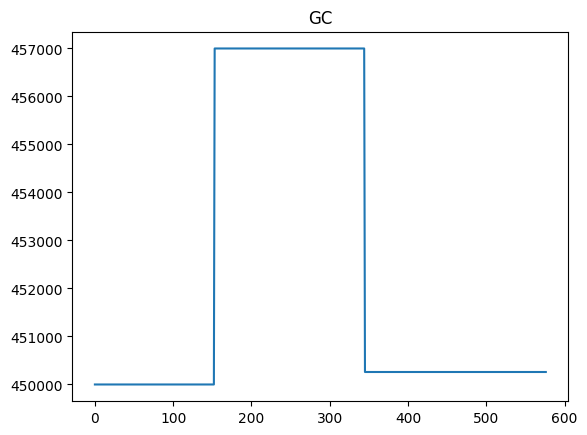

In [243]:
plt.plot(equity_c)
plt.title(ASSET)
plt.show()


In [244]:
trades_c_s, equity_c_s = run_backtest_complete_scalein(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)

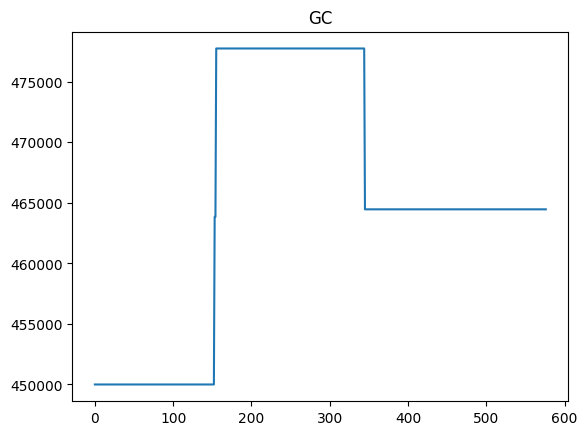

In [245]:
plt.plot(equity_c_s)
plt.title(ASSET)
plt.show()


In [246]:
trades_c_si, equity_c_si = run_backtest_sizing_only(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)

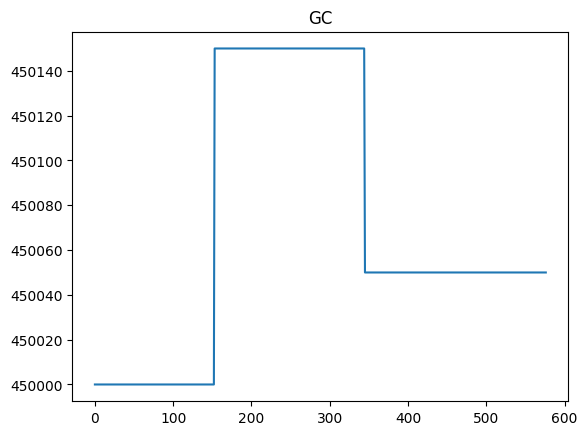

In [247]:
plt.plot(equity_c_si)
plt.title(ASSET)
plt.show()


In [248]:
trades_c_todo, equity_c_todo = run_backtest_scalein_sizing(df_for_bt, specs[ASSET], initial_capital=specs[ASSET]["initial_margin"]*10)

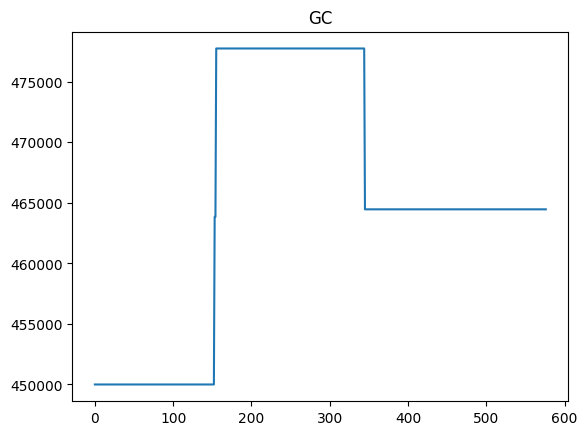

In [249]:
plt.plot(equity_c_todo)
plt.title(ASSET)
plt.show()


In [250]:
# 1. Crear el DataFrame
df = pd.DataFrame({
    "equity_c": equity_c,
    "equity_c_s": equity_c_s,
    "equity_c_si": equity_c_si,
    "equity_c_todo": equity_c_todo
}).astype(float)

# 2. Seleccionar la columna con mayor equity final
best_col = df.iloc[-1].idxmax()

profit = df.iloc[-1].max() - specs[ASSET]["initial_margin"]*10

print("Mejor ganancia:", profit)

equity = df[best_col]

print("Mejor equity:", best_col)

# 3. Calcular MDD
rolling_max = equity.cummax()
drawdown = (rolling_max - equity) / rolling_max
max_dd = drawdown.max()

dd_usd = (rolling_max - equity).max()
eps = 1e-9
ratio = profit / max(dd_usd, eps)
print("Max Drawdown:", dd_usd)

print("Ratio:", ratio)

Mejor ganancia: 14460.000000000058
Mejor equity: equity_c_s
Max Drawdown: 13279.999999999884
Ratio: 1.088855421686761


In [251]:
# equity = pd.Series(equity_c)
equity = equity.dropna()
returns = equity.pct_change().dropna()
vol_daily = returns.std()
vol_annual = vol_daily * np.sqrt(252)
total_return = equity.iloc[-1] / equity.iloc[0] - 1
months = len(equity) / 21  # aprox 21 días de trading por mes
cagr = (1 + total_return)**(12 / months) - 1
sharpe = cagr / vol_annual



In [252]:
rolling_max = equity.cummax()
drawdown = (rolling_max - equity) / rolling_max
max_dd = drawdown.max()

In [253]:
sharpe

np.float64(0.41088013096579595)

In [254]:
cagr

np.float64(0.013909049602301327)

In [255]:
max_dd

np.float64(0.02779754678276863)

In [256]:
calmar = cagr / max_dd


In [257]:
calmar

np.float64(0.500369680497251)

In [258]:
import pandas as pd

trades_df = pd.DataFrame(trades_c)
trades_df["datetime_exit"] = pd.to_datetime(trades_df["datetime_exit"])
trades_df = trades_df.sort_values("datetime_exit").reset_index(drop=True)


In [259]:
trades_df["week"] = trades_df["datetime_exit"].dt.isocalendar().week
trades_df["year"] = trades_df["datetime_exit"].dt.isocalendar().year
weekly = trades_df.groupby(["year", "week"])["pnl_usd"].sum().reset_index()


In [260]:
weekly_pnl = weekly["pnl_usd"].values

blocks, block_size = build_overlapping_blocks(weekly_pnl, block_size=1)
print("block_size usado:", block_size)
print("n_blocks:", len(blocks))

mc = monte_carlo_blocks(blocks, len(weekly_pnl), n_sims=5000)


block_size usado: 1
n_blocks: 2


In [261]:
mc

array([[-6740., -6740.],
       [-6740.,  7000.],
       [-6740., -6740.],
       ...,
       [ 7000.,  7000.],
       [ 7000.,  7000.],
       [ 7000.,  7000.]], shape=(5000, 2))

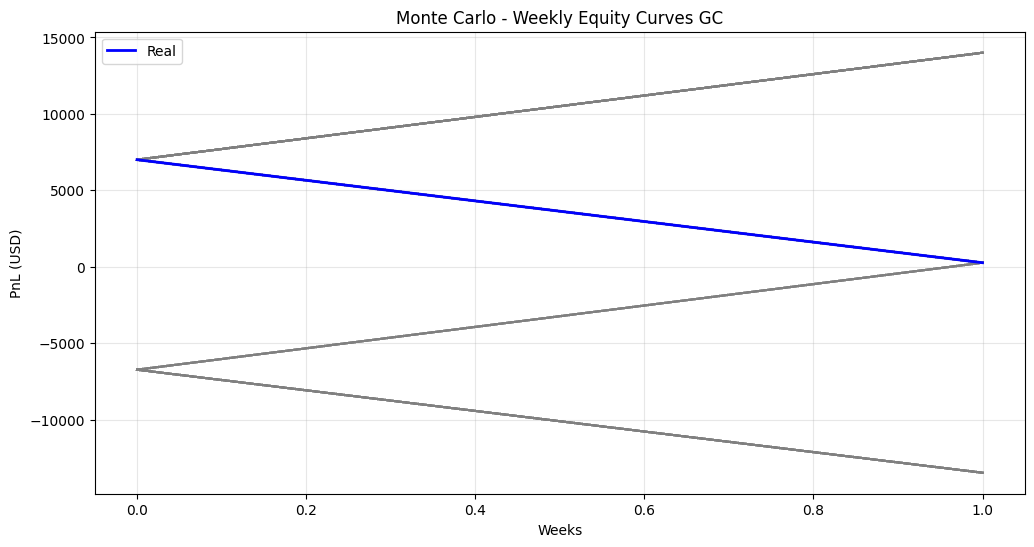

In [262]:

# equity real
real_equity = weekly_pnl.cumsum()

# equity simulada
mc_equity = mc.cumsum(axis=1)

plt.figure(figsize=(12,6))

# muchas curvas simuladas
for i in range(300):   # 300 para no saturar
    plt.plot(mc_equity[i], color="gray", alpha=0.05)

# curva real
plt.plot(real_equity, color="blue", linewidth=2, label="Real")

plt.title(f"Monte Carlo - Weekly Equity Curves {ASSET}")
plt.xlabel("Weeks")
plt.ylabel("PnL (USD)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
